In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [32]:
dummy_matrix = np.array(
    [
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0 ,0, 0]
    ]
)

SE1 = np.array(
    [
        [0, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
    ]
)

SE2 = np.array([
    [1,0,0,0],
    [1,0,0,0],
    [1,0,0,0],
    [1,0,0,0]
]
)

SE3 = np.array([
    [1,1,1,1],
    [0,0,0,0],
    [0,0,0,0],
    [0,0,0,0]
])

SE4 = np.array([
    [0,1,0],
    [0,1,1],
    [0,1,0]
])

# Morphological Operation

In [3]:
SE_3x3 = np.ones((3, 3), dtype=np.uint8)
 
 
def get_default_origin(se: np.ndarray) -> tuple:
    """Return pusat SE sebagai origin default."""
    return (se.shape[0] // 2, se.shape[1] // 2)

In [4]:
def dilate(image: np.ndarray,
           se: np.ndarray = SE_3x3,
           origin: tuple = None) -> np.ndarray:
    """
    origin : (row, col) posisi titik acuan di dalam SE.
             Default = tengah SE.
    """
    img_h, img_w = image.shape
    se_h, se_w   = se.shape
 
    if origin is None:
        origin = get_default_origin(se)
    or_i, or_j = origin
 
    output = np.zeros_like(image)
 
    for i in range(img_h):
        for j in range(img_w):
            if image[i, j] == 1:
                for si in range(se_h):
                    for sj in range(se_w):
                        if se[si, sj] == 1:
                            ni = i + (si - or_i)
                            nj = j + (sj - or_j)
                            if 0 <= ni < img_h and 0 <= nj < img_w:
                                output[ni, nj] = 1
    return output

In [5]:
def erode(image: np.ndarray,
          se: np.ndarray = SE_3x3,
          origin: tuple = None) -> np.ndarray:
    """
    origin : (row, col) posisi titik acuan di dalam SE.
             Default = tengah SE.
    """
    img_h, img_w = image.shape
    se_h, se_w   = se.shape
 
    if origin is None:
        origin = get_default_origin(se)
    or_i, or_j = origin
 
    output = np.zeros_like(image)
 
    for i in range(img_h):
        for j in range(img_w):
            fit = True
            for si in range(se_h):
                for sj in range(se_w):
                    if se[si, sj] == 1:
                        ni = i + (si - or_i)
                        nj = j + (sj - or_j)
                        if not (0 <= ni < img_h and 0 <= nj < img_w) or image[ni, nj] == 0:
                            fit = False
                            break
                if not fit:
                    break
            output[i, j] = 1 if fit else 0
 
    return output

In [6]:
def opening(image: np.ndarray,
            se: np.ndarray = SE_3x3,
            origin: tuple = None) -> np.ndarray:
    return dilate(erode(image, se, origin), se, origin)


In [7]:
def closing(image: np.ndarray,
            se: np.ndarray = SE_3x3,
            origin: tuple = None) -> np.ndarray:
    return erode(dilate(image, se, origin), se, origin)

In [8]:
def hit_or_miss(image: np.ndarray,
                se_hit: np.ndarray,
                se_miss: np.ndarray,
                origin: tuple = None) -> np.ndarray:
    eroded_hit  = erode(image,     se_hit,  origin)
    eroded_miss = erode(1 - image, se_miss, origin)
    return np.logical_and(eroded_hit, eroded_miss).astype(np.uint8)

In [9]:
def print_matrix(label: str, matrix: np.ndarray) -> None:
    print(f"\n{'='*52}")
    print(f"  {label}")
    print(f"{'='*52}")
    for row in matrix:
        print("  " + " ".join("█" if v else "·" for v in row))
    print()


  Original Image
  · · · · · · · · · · ·
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · █ █ █ █ █ · · █ █ ·
  · · · █ █ █ █ █ █ █ ·
  · · · · █ · · █ █ █ ·
  · · · █ █ █ · · · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



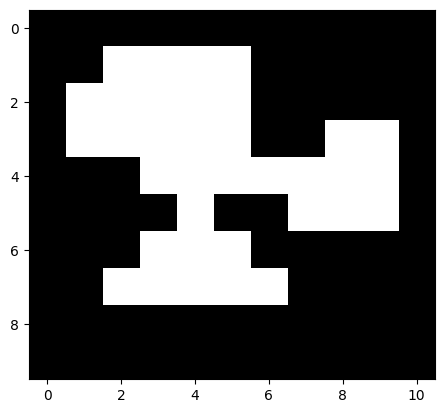

In [10]:
# Contoh penggunaan
print_matrix("Original Image", dummy_matrix)
plt.imshow(dummy_matrix,cmap="gray")


  Eroded Image
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · █ █ █ · · · · · ·
  · · · █ █ · · · · · ·
  · · · · █ · · · █ · ·
  · · · · · · · · · · ·
  · · · · █ · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



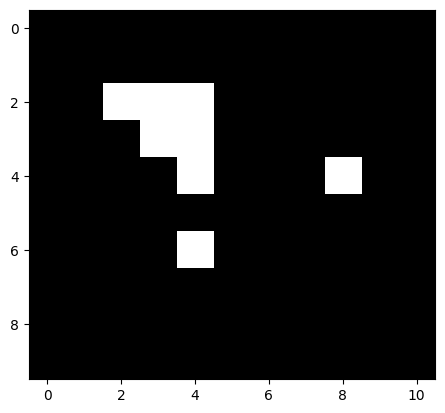

In [11]:
# erotion
eroded_image = erode(dummy_matrix, SE1)
print_matrix("Eroded Image", eroded_image)
plt.imshow(eroded_image,cmap="gray")


  Dilated Image
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ █ · · · ·
  █ █ █ █ █ █ █ · █ █ ·
  █ █ █ █ █ █ █ █ █ █ █
  · █ █ █ █ █ █ █ █ █ █
  · · · █ █ █ █ █ █ █ █
  · · █ █ █ █ █ █ █ █ ·
  · █ █ █ █ █ █ █ · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·



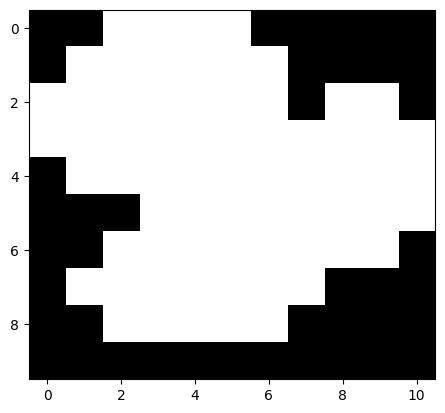

In [12]:
dilated_image = dilate(dummy_matrix, SE1)
print_matrix("Dilated Image", dilated_image)
plt.imshow(dilated_image,cmap="gray")


  Opened Image
  · · · · · · · · · · ·
  · · █ █ █ · · · · · ·
  · █ █ █ █ █ · · · · ·
  · · █ █ █ █ · · █ · ·
  · · · █ █ █ · █ █ █ ·
  · · · · █ · · · █ · ·
  · · · █ █ █ · · · · ·
  · · · · █ · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



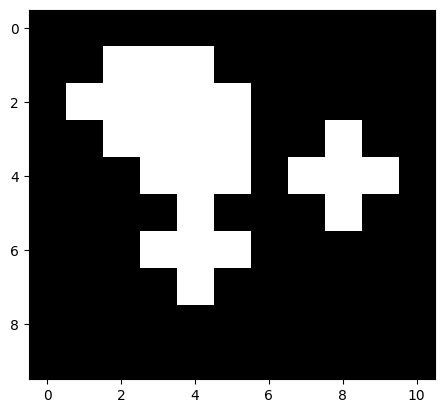

In [13]:
opened_image = opening(dummy_matrix, SE1)
print_matrix("Opened Image", opened_image)
plt.imshow(opened_image,cmap="gray")


  Closed Image
  · · · · · · · · · · ·
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · █ █ █ █ █ █ · █ █ ·
  · · · █ █ █ █ █ █ █ ·
  · · · · █ █ █ █ █ █ ·
  · · · █ █ █ █ █ · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



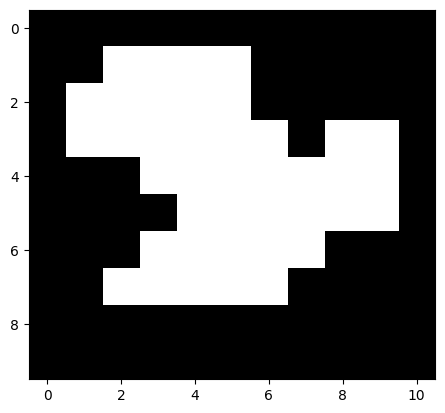

In [14]:
closed_image = closing(dummy_matrix, SE1)
print_matrix("Closed Image", closed_image)
plt.imshow(closed_image,cmap="gray")


  Eroded Image with SE2
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · █ █ █ · · · · ·
  · · · · █ · · · · · ·
  · · · · █ · · · · · ·
  · · · · █ · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



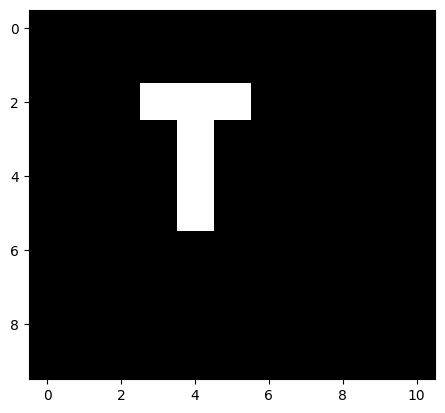

In [15]:
eroded_image2 = erode(dummy_matrix, SE2,origin=(1,0))
print_matrix("Eroded Image with SE2", eroded_image2)
plt.imshow(eroded_image2,cmap="gray")


  Dilated Image with SE2
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · █ █ █ █ █ · · █ █ ·
  · █ █ █ █ █ █ █ █ █ ·
  · █ █ █ █ █ █ █ █ █ ·
  · █ █ █ █ █ █ █ █ █ ·
  · · █ █ █ █ █ █ █ █ ·
  · · █ █ █ █ █ █ █ █ ·
  · · █ █ █ █ █ · · · ·
  · · █ █ █ █ █ · · · ·



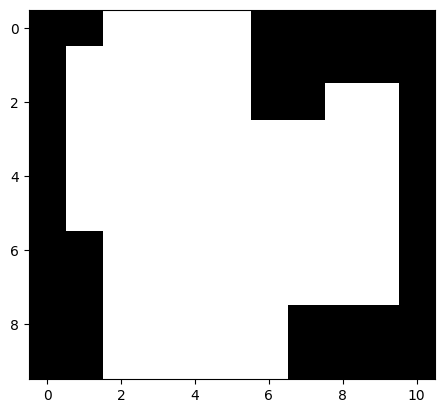

In [16]:
dilated_image2 = dilate(dummy_matrix, SE2,origin=(1,0))
print_matrix("Dilated Image with SE2", dilated_image2)
plt.imshow(dilated_image2,cmap="gray")


  Opened Image with SE2
  · · · · · · · · · · ·
  · · · █ █ █ · · · · ·
  · · · █ █ █ · · · · ·
  · · · █ █ █ · · · · ·
  · · · █ █ █ · · · · ·
  · · · · █ · · · · · ·
  · · · · █ · · · · · ·
  · · · · █ · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



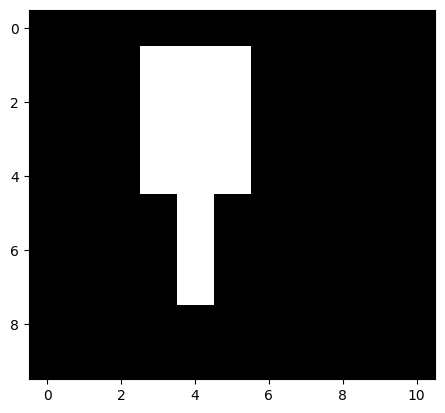

In [17]:
opened_image2 = opening(dummy_matrix, SE2,origin=(1,0))
print_matrix("Opened Image with SE2", opened_image2)
plt.imshow(opened_image2,cmap="gray")



  Closed Image with SE2
  · · · · · · · · · · ·
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · █ █ █ █ █ · · █ █ ·
  · · █ █ █ █ █ █ █ █ ·
  · · █ █ █ █ █ █ █ █ ·
  · · █ █ █ █ █ · · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



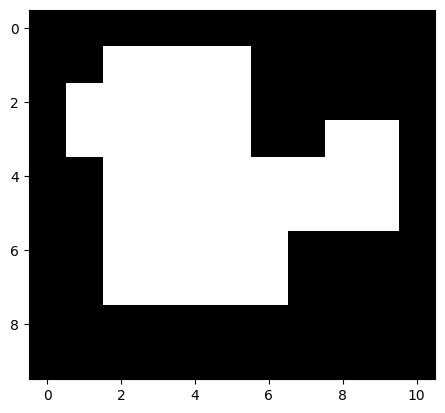

In [18]:
closed_image2 = closing(dummy_matrix, SE2,origin=(1,0))
print_matrix("Closed Image with SE2", closed_image2)
plt.imshow(closed_image2,cmap="gray")


  Eroded Image with SE3
  · · · · · · · · · · ·
  · · · · █ · · · · · ·
  · · · █ █ · · · · · ·
  · · · █ █ · · · · · ·
  · · · · · █ █ █ █ · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · █ █ · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



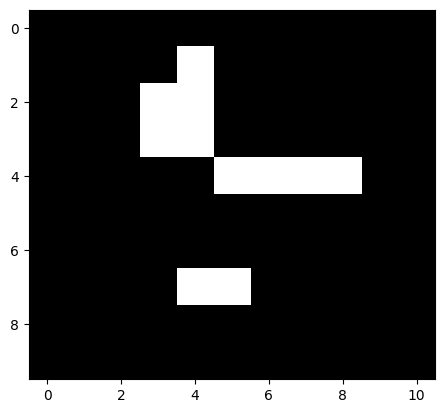

In [28]:
eroded_image3 = erode(dummy_matrix, SE3,origin=(0,2))
print_matrix("Eroded Image with SE3", eroded_image3)
plt.imshow(eroded_image3,cmap="gray")


  Dilated Image with SE3
  · · · · · · · · · · ·
  █ █ █ █ █ █ █ · · · ·
  █ █ █ █ █ █ █ · · · ·
  █ █ █ █ █ █ █ █ █ █ █
  · █ █ █ █ █ █ █ █ █ █
  · · █ █ █ █ █ █ █ █ █
  · █ █ █ █ █ █ · · · ·
  █ █ █ █ █ █ █ █ · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



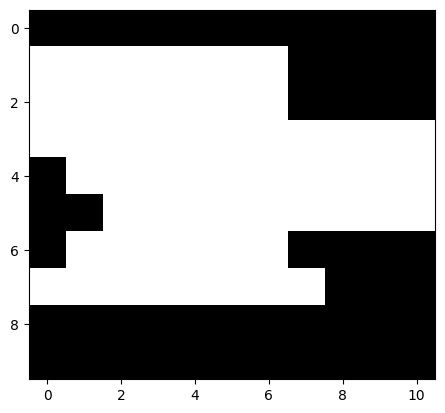

In [29]:
dilated_image3 = dilate(dummy_matrix, SE3,origin=(0,2))
print_matrix("Dilated Image with SE3", dilated_image3)
plt.imshow(dilated_image3,cmap="gray")


  Opening Image with SE3
  · · · · · · · · · · ·
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · · · █ █ █ █ █ █ █ ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



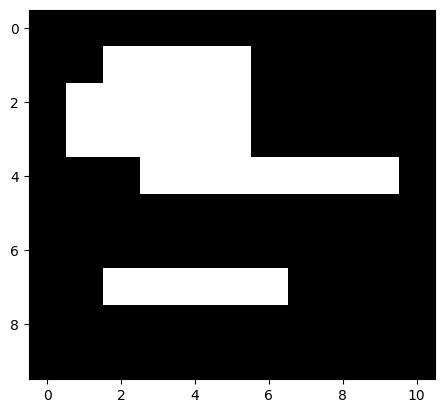

In [30]:
opening_image3 = opening(dummy_matrix, SE3,origin=(0,2))
print_matrix("Opening Image with SE3", opening_image3)
plt.imshow(opening_image3,cmap="gray")


  Closed Image with SE3
  · · · · · · · · · · ·
  · · █ █ █ █ · · · · ·
  · · █ █ █ █ · · · · ·
  · · █ █ █ █ █ █ █ █ ·
  · · · █ █ █ █ █ █ █ ·
  · · · · █ █ █ █ █ █ ·
  · · · █ █ █ · · · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



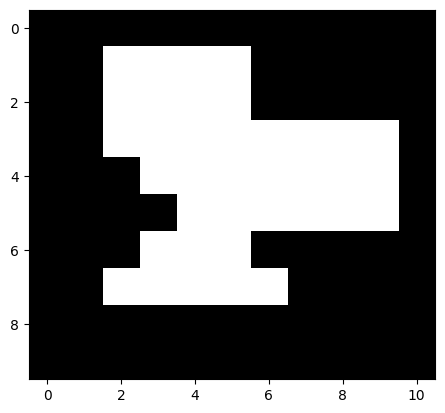

In [31]:
closed_image3 = closing(dummy_matrix, SE3,origin=(0,2))
print_matrix("Closed Image with SE3", closed_image3)
plt.imshow(closed_image3,cmap="gray")


  Eroded Image with SE4
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · █ █ █ · · · · · ·
  · · · █ █ · · · · · ·
  · · · · █ · · · █ · ·
  · · · · · · · · · · ·
  · · · · █ · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



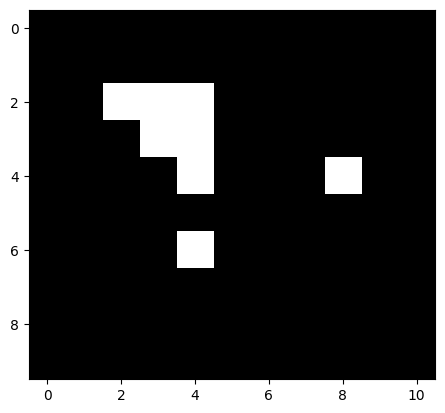

In [33]:
eroded_image4 = erode(dummy_matrix, SE4)
print_matrix("Eroded Image with SE4", eroded_image4)
plt.imshow(eroded_image4,cmap="gray")


  Dilated Image with SE4
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ █ · · · ·
  · █ █ █ █ █ █ · █ █ ·
  · █ █ █ █ █ █ █ █ █ █
  · █ █ █ █ █ █ █ █ █ █
  · · · █ █ █ █ █ █ █ █
  · · █ █ █ █ █ █ █ █ ·
  · · █ █ █ █ █ █ · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·



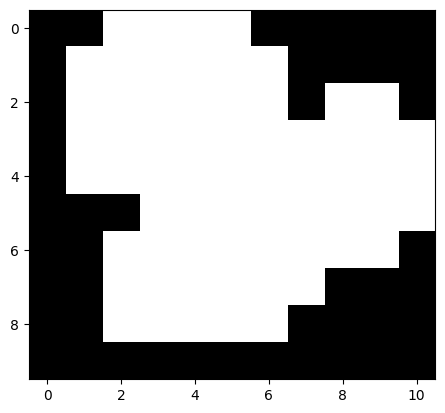

In [34]:
dilated_image4 = dilate(dummy_matrix, SE4)
print_matrix("Dilated Image with SE4", dilated_image4)
plt.imshow(dilated_image4,cmap="gray")


  Opened Image with SE4
  · · · · · · · · · · ·
  · · █ █ █ · · · · · ·
  · · █ █ █ █ · · · · ·
  · · █ █ █ █ · · █ · ·
  · · · █ █ █ · · █ █ ·
  · · · · █ · · · █ · ·
  · · · · █ █ · · · · ·
  · · · · █ · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



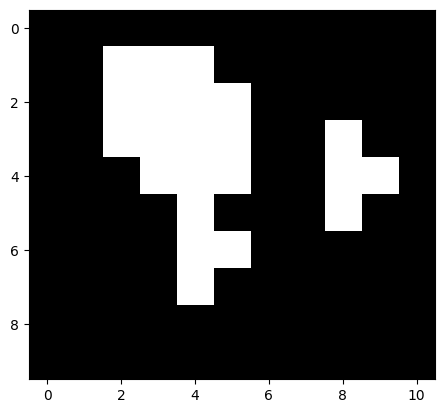

In [35]:
opened_image4 = opening(dummy_matrix, SE4)
print_matrix("Opened Image with SE4", opened_image4)
plt.imshow(opened_image4,cmap="gray")


  Closed Image with SE4
  · · · · · · · · · · ·
  · · █ █ █ █ · · · · ·
  · █ █ █ █ █ · · · · ·
  · █ █ █ █ █ █ · █ █ ·
  · · · █ █ █ █ █ █ █ ·
  · · · █ █ █ █ █ █ █ ·
  · · · █ █ █ █ █ · · ·
  · · █ █ █ █ █ · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·



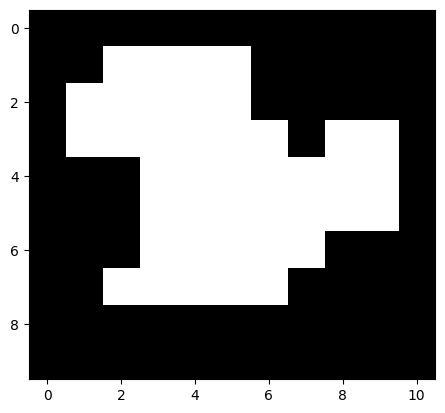

In [37]:
closed_image4 = closing(dummy_matrix, SE4)
print_matrix("Closed Image with SE4", closed_image4)
plt.imshow(closed_image4,cmap="gray")

# Hit-or-Miss Transform (with Don't Care Support)

In [19]:
def erode_with_mask(image: np.ndarray,
                    se: np.ndarray,
                    mask: np.ndarray,
                    origin: tuple = None) -> np.ndarray:
    """
    Erosi dengan mask: hanya periksa posisi di mana mask == 1.
    Digunakan internal untuk hit_or_miss dengan dont care.
    """
    img_h, img_w = image.shape
    se_h, se_w   = se.shape

    if origin is None:
        origin = get_default_origin(se)
    or_i, or_j = origin

    output = np.zeros_like(image)

    for i in range(img_h):
        for j in range(img_w):
            fit = True
            for si in range(se_h):
                for sj in range(se_w):
                    if mask[si, sj] == 1:
                        ni = i + (si - or_i)
                        nj = j + (sj - or_j)
                        if se[si, sj] == 1:
                            if not (0 <= ni < img_h and 0 <= nj < img_w) or image[ni, nj] == 0:
                                fit = False
                                break
                        else:
                            if not (0 <= ni < img_h and 0 <= nj < img_w) or image[ni, nj] == 1:
                                fit = False
                                break
                if not fit:
                    break
            output[i, j] = 1 if fit else 0

    return output


In [20]:
def hit_or_miss(image: np.ndarray,
                se_hit: np.ndarray,
                se_miss: np.ndarray,
                origin: tuple = None) -> np.ndarray:
    """
    Hit-or-Miss Transform dengan dukungan dont care.
    Gunakan nilai -1 untuk menandai dont care di se_hit dan se_miss.

    Encoding:
        se_hit  : 1 = foreground (harus 1 di image), -1 = dont care
        se_miss : 1 = background (harus 0 di image), -1 = dont care

    Algoritma:
        mask_hit  = posisi aktif di se_hit  (bukan dont care)
        mask_miss = posisi aktif di se_miss (bukan dont care)
        result = erode_masked(image,       se_hit,  mask_hit)
                 AND
                 erode_masked(1 - image,   se_miss, mask_miss)
    """
    mask_hit  = (se_hit  != -1).astype(np.uint8)
    mask_miss = (se_miss != -1).astype(np.uint8)

    se_hit_clean  = np.where(se_hit  == -1, 0, se_hit ).astype(np.uint8)
    se_miss_clean = np.where(se_miss == -1, 0, se_miss).astype(np.uint8)

    eroded_hit  = erode_with_mask(image,     se_hit_clean,  mask_hit,  origin)
    eroded_miss = erode_with_mask(1 - image, se_miss_clean, mask_miss, origin)

    return np.logical_and(eroded_hit, eroded_miss).astype(np.uint8)


# Hit or miss dari soal Cased Based


  Hit-or-Miss Result (SE Pattern)
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · █ · · · · · · · · ·
  · · · █ · · · · · · ·
  · · · · · · · █ · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·

Piksel yang match (baris, kolom): [[3, 1], [4, 3], [5, 7]]


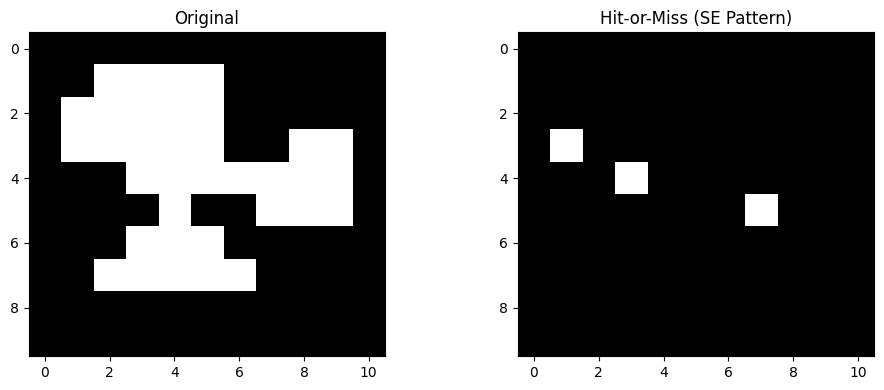

In [21]:
# SE Hit-or-Miss: pola South-East
# -1 = dont care
SE_hit_SE = np.array([
    [-1,  1, -1],   # row0: col1 harus 1, col0 & col2 dont care
    [ 0,  1,  1],   # row1: col0 harus 0, col1 & col2 harus 1 (origin di col1)
    [ 0,  0, -1],   # row2: col0 & col1 harus 0, col2 dont care
])

SE_miss_SE = np.array([
    [-1,  0, -1],   # row0: col1 harus 0, lainnya dont care
    [ 1,  0,  0],   # row1: col0 harus 1 (bg), col1 & col2 bukan bg
    [ 1,  1, -1],   # row2: col0 & col1 harus 1 (bg), col2 dont care
])

result_hm = hit_or_miss(dummy_matrix, SE_hit_SE, SE_miss_SE)

print_matrix('Hit-or-Miss Result (SE Pattern)', result_hm)
print('Piksel yang match (baris, kolom):', np.argwhere(result_hm).tolist())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(dummy_matrix, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Hit-or-Miss (SE Pattern)')
plt.imshow(result_hm, cmap='gray')
plt.tight_layout()
plt.show()



  Hit-or-Miss Result (SE Pattern)
  · · · · · · · · · · ·
  · · · · · █ · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · █ ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · █ · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·

Piksel yang match (baris, kolom): [[1, 5], [3, 9], [6, 5]]


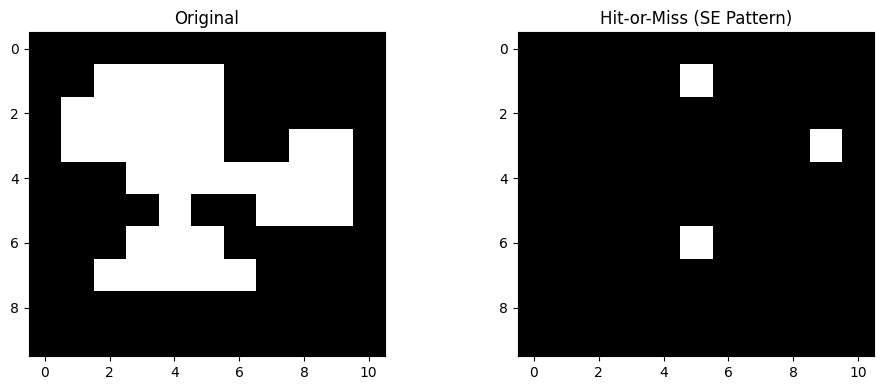

In [22]:
# SE Hit-or-Miss: pola South-East
# -1 = dont care
SE_hit_SE = np.array([
    [-1,  0, 0],   # row0: col1 harus 1, col0 & col2 dont care
    [ 1,  1,  0],   # row1: col0 harus 0, col1 & col2 harus 1 (origin di col1)
    [ -1,  1, -1],   # row2: col0 & col1 harus 0, col2 dont care
])

SE_miss_SE = np.array([
    [-1,  1, 1],   # row0: col1 harus 0, lainnya dont care
    [ 0,  0,  1],   # row1: col0 harus 1 (bg), col1 & col2 bukan bg
    [ -1,  0, -1],   # row2: col0 & col1 harus 1 (bg), col2 dont care
])

result_hm = hit_or_miss(dummy_matrix, SE_hit_SE, SE_miss_SE)

print_matrix('Hit-or-Miss Result (SE Pattern)', result_hm)
print('Piksel yang match (baris, kolom):', np.argwhere(result_hm).tolist())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(dummy_matrix, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Hit-or-Miss (SE Pattern)')
plt.imshow(result_hm, cmap='gray')
plt.tight_layout()
plt.show()



  Hit-or-Miss Result (SE Pattern)
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · █ ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·

Piksel yang match (baris, kolom): [[5, 9]]


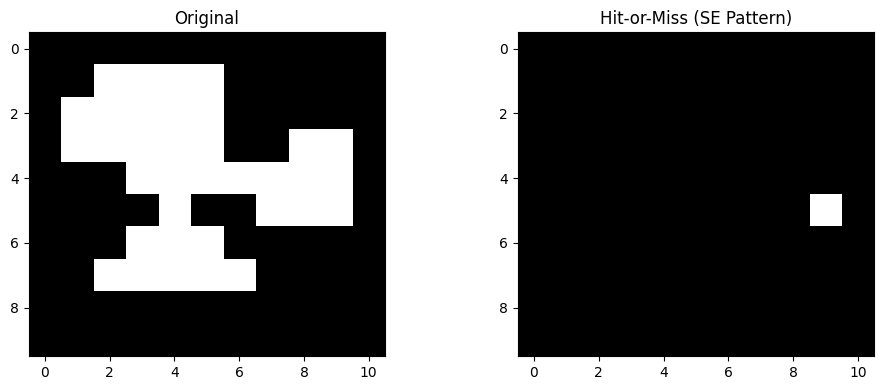

In [23]:
# SE Hit-or-Miss: pola South-East
# -1 = dont care
SE_hit_SE = np.array([
    [-1,  1, -1],   # row0: col1 harus 1, col0 & col2 dont care
    [ 1,  1,  0],   # row1: col0 harus 0, col1 & col2 harus 1 (origin di col1)
    [ -1,  0, 0],   # row2: col0 & col1 harus 0, col2 dont care
])

SE_miss_SE = np.array([
    [-1,  0, -1],   # row0: col1 harus 0, lainnya dont care
    [ 0,  0,  1],   # row1: col0 harus 1 (bg), col1 & col2 bukan bg
    [ -1,  1, 1],   # row2: col0 & col1 harus 1 (bg), col2 dont care
])

result_hm = hit_or_miss(dummy_matrix, SE_hit_SE, SE_miss_SE)

print_matrix('Hit-or-Miss Result (SE Pattern)', result_hm)
print('Piksel yang match (baris, kolom):', np.argwhere(result_hm).tolist())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(dummy_matrix, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Hit-or-Miss (SE Pattern)')
plt.imshow(result_hm, cmap='gray')
plt.tight_layout()
plt.show()



  Hit-or-Miss Result (SE Pattern)
  · · · · · · · · · · ·
  · · █ · · · · · · · ·
  · █ · · · · · · · · ·
  · · · · · · · · █ · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · █ · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·
  · · · · · · · · · · ·

Piksel yang match (baris, kolom): [[1, 2], [2, 1], [3, 8], [6, 3]]


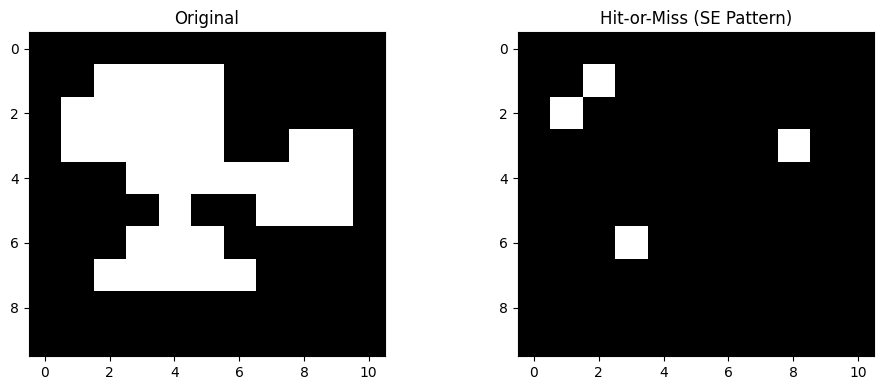

In [24]:
# SE Hit-or-Miss: pola South-East
# -1 = dont care
SE_hit_SE = np.array([
    [0,  0, -1],   # row0: col1 harus 1, col0 & col2 dont care
    [ 0,  1,  1],   # row1: col0 harus 0, col1 & col2 harus 1 (origin di col1)
    [ -1,  1, -1],   # row2: col0 & col1 harus 0, col2 dont care
])

SE_miss_SE = np.array([
    [1,  1, -1],   # row0: col1 harus 0, lainnya dont care
    [ 1,  0,  0],   # row1: col0 harus 1 (bg), col1 & col2 bukan bg
    [ -1,  0, -1],   # row2: col0 & col1 harus 1 (bg), col2 dont care
])

result_hm = hit_or_miss(dummy_matrix, SE_hit_SE, SE_miss_SE)

print_matrix('Hit-or-Miss Result (SE Pattern)', result_hm)
print('Piksel yang match (baris, kolom):', np.argwhere(result_hm).tolist())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(dummy_matrix, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Hit-or-Miss (SE Pattern)')
plt.imshow(result_hm, cmap='gray')
plt.tight_layout()
plt.show()
